In [1]:
import subprocess
import sys

pakketten = [
    "kagglehub",
    "pandas",
    "matplotlib",
    "seaborn",
    "scikit-learn",
    "lime"
]

subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + pakketten)
print("✅ Alle pakketten geïnstalleerd")

✅ Alle pakketten geïnstalleerd


# Automatische classificatie van IT-servicedesktickets met NLP en DistilBERT

**Naam:** Ertugrul Demirci  
**Opleiding:** Business IT & Management Avans Hogeschool  
**Periode:** P3: Slim beslissen met AI (High-Tech AI)

---

## Het probleem

Voor dit project heb ik gekeken naar iets wat bij veel IT-servicedesks speelt:
het handmatig sorteren van binnenkomende meldingen.

Stel je werkt bij een IT-afdeling. Elke dag stromen er tientallen of honderden
tickets binnen van collega's — iemand kan niet inloggen, een printer doet het
niet, Outlook crasht. Al die meldingen komen als gewone tekst binnen en iemand
moet ze lezen, beoordelen en in de juiste categorie zetten. Dat kost veel tijd,
gaat regelmatig fout en loopt vast zodra het druk wordt.

## Mijn oplossing

Ik heb een AI-model gebouwd dat die categorisering automatisch doet op basis
van de tekst van een ticket. Ik gebruik hiervoor **DistilBERT**, een model dat
al enorm veel tekst heeft gelezen en daardoor goed begrijpt wat er in een ticket staat.

Het model neemt de beslissing niet over. De medewerker blijft zelf verantwoordelijk.
Het model doet een voorstel met een zekerheidspercentage, en de medewerker beslist.

## Welke AI-technieken gebruik ik?

| Techniek | Hoe ik het gebruik |
|---|---|
| **Natural Language Processing (NLP)** | Tickettekst verwerken en klaarmaken voor het model |
| **Transformers (DistilBERT)** | Het model dat ik verder train op mijn eigen dataset |
| **Explainable AI (LIME)** | Laten zien welke woorden de voorspelling sturen |

Hiermee dek ik drie van de vijf vereiste AI-technieken af.

## Waarom DistilBERT?

DistilBERT is een kleinere versie van BERT — 40% kleiner maar nog steeds bijna
even goed. Dat maakt het haalbaar zonder enorme rekenkracht.

## De dataset

Ik gebruik de **IT Service Ticket Classification Dataset** van Kaggle (adisongoh).
Dit zijn echte servicedesktickets die al voorzien zijn van de juiste categorie.

## Sectie 2 — Data laden en verkennen

### 2A — Dataset downloaden

Ik haal de dataset op via kagglehub. Dat is de officiële manier om
Kaggle-datasets te downloaden vanuit Python. Met één functieaanroep
regelt het zelf de authenticatie, download en het uitpakken.

Ik heb wel een kaggle.json nodig. Mijn persoonlijke API-sleutel van Kaggle.
Die download ik via mijn profiel op kaggle.com onder Settings -> API.

In [2]:
import os
import json
import kagglehub

# Zorg dat kaggle.json in de standaardmap staat
# Standaard zoekt kagglehub zelf op: C:\Users\[jouwnaam]\.kaggle\kaggle.json
# Als dat bestand daar staat hoef je niets aan te passen

pad = kagglehub.dataset_download("adisongoh/it-service-ticket-classification-dataset")

print(f"✅ Dataset opgeslagen in: {pad}")
print("\nBestanden in de map:")
for bestand in os.listdir(pad):
    grootte = os.path.getsize(os.path.join(pad, bestand)) / 1024
    print(f"  • {bestand}  ({grootte:.1f} KB)")

c:\Users\tatar\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Dataset opgeslagen in: C:\Users\tatar\.cache\kagglehub\datasets\adisongoh\it-service-ticket-classification-dataset\versions\1

Bestanden in de map:
  • all_tickets_processed_improved_v3.csv  (14227.5 KB)


### 2B — Data inladen

Nu laad ik het CSV-bestand in als een pandas DataFrame (gewoon een tabel),
vergelijkbaar met Excel. Rijen zijn tickets, kolommen zijn de eigenschappen.

Met `.head(3)` kijk ik naar de eerste drie rijen zodat ik de kolomnamen weet.

In [3]:
import pandas as pd
import os

# Zoek automatisch het eerste CSV-bestand in de map
csv_bestanden = [f for f in os.listdir(pad) if f.endswith(".csv")]

print("Gevonden CSV-bestanden:")
for f in csv_bestanden:
    print(f"  • {f}")

# Laad het eerste (of enige) CSV-bestand automatisch
CSV_PAD = os.path.join(pad, csv_bestanden[0])
print(f"\nGebruik: {CSV_PAD}")

df = pd.read_csv(CSV_PAD)

print(f"\nGrootte dataset: {df.shape[0]} rijen × {df.shape[1]} kolommen")
print(f"\nKolomnamen: {df.columns.tolist()}")
print(f"\nEerste 3 rijen:")
df.head(3)

Gevonden CSV-bestanden:
  • all_tickets_processed_improved_v3.csv

Gebruik: C:\Users\tatar\.cache\kagglehub\datasets\adisongoh\it-service-ticket-classification-dataset\versions\1\all_tickets_processed_improved_v3.csv

Grootte dataset: 47837 rijen × 2 kolommen

Kolomnamen: ['Document', 'Topic_group']

Eerste 3 rijen:


,Document,Topic_group
0,connection with icon icon dear please setup ic...,Hardware
1,work experience user work experience user hi w...,Access
2,requesting for meeting requesting meeting hi p...,Hardware


### 2C — Kolomnamen standaardiseren

De dataset heeft z'n eigen kolomnamen: `Document` voor de tekst en `Topic_group`
voor de categorie. Ik hernoem die naar `text` en `label` zodat de rest van mijn
notebook altijd met vaste namen werkt.

In [4]:
TEXT_KOLOM  = "Document"      # kolom met de tickettekst
LABEL_KOLOM = "Topic_group"   # kolom met de categorie

# Controleer of de kolommen bestaan
assert TEXT_KOLOM in df.columns, \
    f"❌ Kolom '{TEXT_KOLOM}' niet gevonden! Beschikbaar: {df.columns.tolist()}"
assert LABEL_KOLOM in df.columns, \
    f"❌ Kolom '{LABEL_KOLOM}' niet gevonden! Beschikbaar: {df.columns.tolist()}"

df = df.rename(columns={TEXT_KOLOM: "text", LABEL_KOLOM: "label"})
df = df[["text", "label"]].dropna().reset_index(drop=True)

print(f"✅ Kolommen hernoemd naar 'text' en 'label'")
print(f"Rijen na selectie: {len(df)}")
print(f"\nCategorieën ({df['label'].nunique()} stuks):")
print(df["label"].value_counts().to_string())

✅ Kolommen hernoemd naar 'text' en 'label'
Rijen na selectie: 47837

Categorieën (8 stuks):
label
Hardware                 13617
HR Support               10915
Access                    7125
Miscellaneous             7060
Storage                   2777
Purchase                  2464
Internal Project          2119
Administrative rights     1760


### 2D — Categorieverdeling visualiseren

Ik maak twee grafieken om te zien hoe de tickets verdeeld zijn over de categorieën.

Dit is belangrijk om te weten of de dataset balanced is (alle categorieën
ongeveer even groot) of imbalanced (sommige veel groter dan andere).

Als één categorie veel groter is, kan het model lui worden en altijd die grote
categorie voorspellen. Dit compenseer ik later met `class_weight='balanced'`.

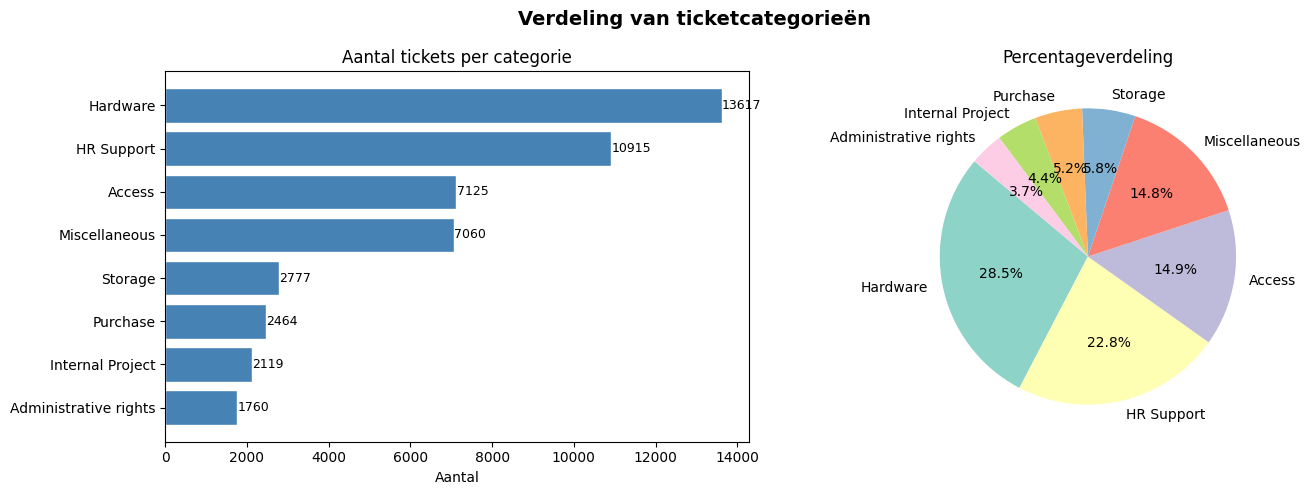

✅ Grafiek opgeslagen als categorie_verdeling.png


In [5]:
import matplotlib.pyplot as plt

fig, assen = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Verdeling van ticketcategorieën", fontsize=14, fontweight="bold")

aantallen = df["label"].value_counts()

# Staafdiagram
balken = assen[0].barh(
    aantallen.index, aantallen.values,
    color="steelblue", edgecolor="white"
)
assen[0].set_title("Aantal tickets per categorie")
assen[0].set_xlabel("Aantal")
assen[0].invert_yaxis()
for balk, waarde in zip(balken, aantallen.values):
    assen[0].text(
        waarde + 5, balk.get_y() + balk.get_height() / 2,
        str(waarde), va="center", fontsize=9
    )

# Taartdiagram
assen[1].pie(
    aantallen.values,
    labels=aantallen.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=plt.cm.Set3.colors[:len(aantallen)]
)
assen[1].set_title("Percentageverdeling")

plt.tight_layout()
plt.savefig("categorie_verdeling.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Grafiek opgeslagen als categorie_verdeling.png")

### 2E — Tekstlengte analyseren

Ik kijk hoe lang de tickets gemiddeld zijn in karakters en woorden.

Dit is relevant voor DistilBERT, want dat model kan maximaal 512 tokenns verwerken
(zo'n 380 woorden). Langere tickets worden afgekapt. Als de meeste tickets korter
zijn dan die grens hoef ik hier niets mee te doen.

Statistieken tekstlengte (karakters):
count    47837.0
mean       291.9
std        388.2
min          7.0
25%        110.0
50%        175.0
75%        304.0
max       7015.0
Name: tekst_lengte, dtype: float64

Statistieken woordaantal:
count    47837.0
mean        43.6
std         56.7
min          2.0
25%         17.0
50%         26.0
75%         46.0
max        981.0
Name: woord_aantal, dtype: float64

Tickets langer dan DistilBERT-grens (>380 woorden): 0.4%


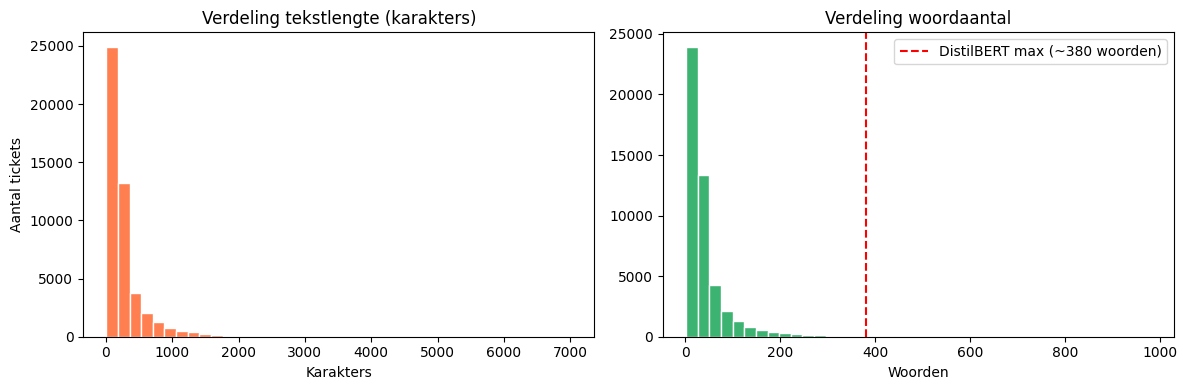

In [6]:
df["tekst_lengte"] = df["text"].astype(str).apply(len)
df["woord_aantal"] = df["text"].astype(str).apply(lambda x: len(x.split()))

print("Statistieken tekstlengte (karakters):")
print(df["tekst_lengte"].describe().round(1))

print("\nStatistieken woordaantal:")
print(df["woord_aantal"].describe().round(1))

pct_te_lang = (df["woord_aantal"] > 380).mean() * 100
print(f"\nTickets langer dan DistilBERT-grens (>380 woorden): {pct_te_lang:.1f}%")

fig, assen = plt.subplots(1, 2, figsize=(12, 4))

assen[0].hist(df["tekst_lengte"], bins=40, color="coral", edgecolor="white")
assen[0].set_title("Verdeling tekstlengte (karakters)")
assen[0].set_xlabel("Karakters")
assen[0].set_ylabel("Aantal tickets")

assen[1].hist(df["woord_aantal"], bins=40, color="mediumseagreen", edgecolor="white")
assen[1].axvline(380, color="red", linestyle="--", label="DistilBERT max (~380 woorden)")
assen[1].set_title("Verdeling woordaantal")
assen[1].set_xlabel("Woorden")
assen[1].legend()

plt.tight_layout()
plt.show()

## Sectie 3 — Data opschoning en voorbereiding

### 3A — Duplicaten en missende waarden verwijderen

Voordat ik ga modelleren begin ik met het opschonen van data en het controleren van de datakwaliteit.

Ik verwijder:
- Missende waarden (een model kan niet trainen op een lege tekst)
- Duplicaten (als hetzelfde ticket in de trainset én testset zit, dan
  herkent het model hem gewoon. Dat geeft namelijk een oneerlijk resultaat)

In [7]:
import re

print(f"Rijen voor opschoning: {len(df)}")
print(f"\nMissende waarden:\n{df[['text', 'label']].isnull().sum()}")
print(f"\nDuplicaten (zelfde tekst + label): {df.duplicated(subset=['text', 'label']).sum()}")

df = df.drop_duplicates(subset=["text", "label"])
df = df.dropna(subset=["text", "label"])
df = df.reset_index(drop=True)

print(f"\nRijen na opschoning: {len(df)}")

Rijen voor opschoning: 47837

Missende waarden:
text     0
label    0
dtype: int64

Duplicaten (zelfde tekst + label): 0

Rijen na opschoning: 47837


### 3B — Tekstnormalisatie

Ik pas een lichte opschoning toe op de tekst:

| Stap | Wat het doet | Waarom |
|---|---|---|
| Kleine letters | "Network" en "network" zijn hetzelfde | Minder variatie |
| URLs verwijderen | Links weghalen | Zeggen niets over de categorie |
| Leestekens → spatie | Punten en uitroeptekens vervangen | Minder ruis |
| Dubbele spaties opruimen | Meerdere spaties → één | Schone invoer |

Ik houd het bewust licht. DistilBERT begrijpt taal het best als het op echte
taal lijkt. "Not working" is echt iets anders dan alleen "working".

In [8]:
def schoon_tekst(tekst: str) -> str:
    tekst = str(tekst)
    tekst = tekst.lower()
    tekst = re.sub(r"http\S+|www\.\S+", " ", tekst)
    tekst = re.sub(r"[^\w\s]", " ", tekst)
    tekst = re.sub(r"\s+", " ", tekst).strip()
    return tekst

df["text_clean"] = df["text"].apply(schoon_tekst)

print("Origineel:")
print(df.loc[0, "text"])
print("\nNa opschoning:")
print(df.loc[0, "text_clean"])

Origineel:
connection with icon icon dear please setup icon per icon engineers please let other details needed thanks lead

Na opschoning:
connection with icon icon dear please setup icon per icon engineers please let other details needed thanks lead


### 3C — Labels omzetten naar nummers

Machine learning werkt met getallen, niet met tekst. `LabelEncoder` vertaalt
de categorienamen automatisch naar nummers, bijvoorbeeld "Hardware" -> 0.

Ik sla de koppeling op zodat ik later in de demo en bij LIME die nummers
weer terug kan vertalen naar leesbare namen.

In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["label_id"] = le.fit_transform(df["label"])

print("Label encoding:")
for naam, nummer in zip(le.classes_, le.transform(le.classes_)):
    print(f"  {nummer:>2}  →  {naam}")

NUM_KLASSEN = len(le.classes_)
print(f"\nTotaal aantal klassen: {NUM_KLASSEN}")

Label encoding:
   0  →  Access
   1  →  Administrative rights
   2  →  HR Support
   3  →  Hardware
   4  →  Internal Project
   5  →  Miscellaneous
   6  →  Purchase
   7  →  Storage

Totaal aantal klassen: 8


### 3D — Train / Validatie / Test split (70% / 15% / 15%)

Ik verdeel de data in drie groepen:

| Set | Aandeel | Waarvoor |
|---|---|---|
| **Train** | 70% | Het model leert hierop |
| **Validatie** | 15% | Ik check de voortgang tijdens het trainen |
| **Test** | 15% | Eenmalige finale evaluatie achteraf |

Ik gebruik `stratify=y` zodat de verhouding van categorieën in elke groep
gelijk blijft aan de originele dataset. Zonder dit kan een kleine categorie
per toeval ontbreken in de testset.

De testset gebruik ik pas één keer, helemaal aan het einde. Zo voorkom ik
dat ik het model onbewust afstemt op de testdata (dit heet data leakage).

In [10]:
from sklearn.model_selection import train_test_split
import numpy as np

X = np.array(df["text_clean"].tolist())
y = np.array(df["label_id"].tolist(), dtype=int)

# Eerste split: 85% voor train+val, 15% voor test
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

# Tweede split: van de 85% → 70% train en 15% validatie
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.1765,
    random_state=42,
    stratify=y_trainval
)

totaal = len(X)
print(f"Train:      {len(X_train):>5} samples  ({len(X_train)/totaal*100:.1f}%)")
print(f"Validatie:  {len(X_val):>5} samples  ({len(X_val)/totaal*100:.1f}%)")
print(f"Test:       {len(X_test):>5} samples  ({len(X_test)/totaal*100:.1f}%)")
print(f"Totaal:     {totaal:>5} samples  (100%)")

Train:      33484 samples  (70.0%)
Validatie:   7177 samples  (15.0%)
Test:        7176 samples  (15.0%)
Totaal:     47837 samples  (100%)


## Sectie 4 — Baseline model: TF-IDF + Logistic Regression

### 4A — TF-IDF vectorisatie

Voordat een model tekst kan verwerken moet die omgezet worden naar getallen.
Ik gebruik TF-IDF (Term Frequency–Inverse Document Frequency):

Een woord dat veel voorkomt in één ticket maar weinig in andere tickets,
krijgt een hoge score. Veelgebruikte woorden zoals "de" of "the" krijgen
een lage score (die zeggen niets over de categorie).

Ik gebruik ook bigrammen (woordcombinaties zoals "not working"). Dat geeft
meer context dan aparte, losse woorden.

Belangrijk: ik fit de TF-IDF alleen op de trainset. De val/testset transformeer
ik daarna met dezelfde instellingen. Zou ik dat niet doen, dan lekt er informatie
door uit de testdata.

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=15_000,   # top 15.000 meest informatieve woorden/woordparen
    ngram_range=(1, 2),    # unigrammen én bigrammen
    sublinear_tf=True      # log-schaling zodat één heel frequent woord niet domineert
)

X_train_tfidf = tfidf.fit_transform(X_train)  # fit + transform op trainset
X_val_tfidf   = tfidf.transform(X_val)        # alleen transform, nooit fit
X_test_tfidf  = tfidf.transform(X_test)       # alleen transform, nooit fit

print(f"Elke ticket is nu een vector van {X_train_tfidf.shape[1]:,} getallen")
print(f"Trainmatrix:     {X_train_tfidf.shape[0]:,} tickets × {X_train_tfidf.shape[1]:,} features")
print(f"Validatiematrix: {X_val_tfidf.shape[0]:,} tickets × {X_val_tfidf.shape[1]:,} features")
print(f"Testmatrix:      {X_test_tfidf.shape[0]:,} tickets × {X_test_tfidf.shape[1]:,} features")

Elke ticket is nu een vector van 15,000 getallen
Trainmatrix:     33,484 tickets × 15,000 features
Validatiematrix: 7,177 tickets × 15,000 features
Testmatrix:      7,176 tickets × 15,000 features


### 4B — Logistic Regression trainen

Als baseline gebruik ik Logistic Regression. Dit model kijkt welke woorden
het sterkst samenhangen met welke categorie en maakt daar een voorspelling op.

Ik gebruik dit als vertrekpunt: kan DistilBERT het beter dan dit simpelere model?

`class_weight='balanced'` zorgt dat het model niet automatisch de grootste
categorie bevoordeelt.

In [12]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    C=1.0,
    solver="lbfgs",
    class_weight="balanced",
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)
print("✅ Baseline model getraind")

✅ Baseline model getraind


### 4C — Evaluatie op de validatieset

Nu test ik het model op de validatieset (tickets die het nog nooit gezien heeft).
Ik kijk naar een paar metrics:

| Metric | Wat het betekent |
|---|---|
| **Precision** | Van alle tickets die het model als X aanwijst, hoeveel zijn er ook echt X? |
| **Recall** | Van alle echte X-tickets, hoeveel heeft het model gevonden? |
| **F1-score** | Het gemiddelde van precision en recall |
| **Accuracy** | Percentage tickets dat het model correct heeft |

De testset bewaar ik nog. Die gebruik ik pas aan het einde.

In [13]:
from sklearn.metrics import classification_report, accuracy_score

y_val_pred = lr_model.predict(X_val_tfidf)

val_accuracy = accuracy_score(y_val, y_val_pred)

print("BASELINE — VALIDATIESET")
print("=" * 60)
print(f"Accuracy: {val_accuracy:.4f}  ({val_accuracy*100:.1f}% correct)\n")
print(classification_report(
    y_val, y_val_pred,
    target_names=le.classes_,
    digits=3
))

BASELINE — VALIDATIESET
Accuracy: 0.8552  (85.5% correct)

                       precision    recall  f1-score   support

               Access      0.890     0.872     0.881      1069
Administrative rights      0.674     0.894     0.769       264
           HR Support      0.890     0.833     0.861      1638
             Hardware      0.865     0.827     0.845      2043
     Internal Project      0.799     0.912     0.852       318
        Miscellaneous      0.805     0.856     0.830      1059
             Purchase      0.949     0.902     0.925       369
              Storage      0.854     0.926     0.888       417

             accuracy                          0.855      7177
            macro avg      0.841     0.878     0.856      7177
         weighted avg      0.859     0.855     0.856      7177



### 4D — Finale evaluatie op de testset

De testset gebruik ik maar één keer (nu, aan het einde van sectie 4).
Dit is de eerlijke definitieve score van het baseline model.

In sectie 7 vergelijk ik dit met DistilBERT.

In [14]:
y_test_pred_baseline = lr_model.predict(X_test_tfidf)
baseline_accuracy    = accuracy_score(y_test, y_test_pred_baseline)

print("BASELINE — TESTSET (definitieve score)")
print("=" * 60)
print(f"Accuracy: {baseline_accuracy:.4f}  ({baseline_accuracy*100:.1f}% correct)\n")
print(classification_report(
    y_test, y_test_pred_baseline,
    target_names=le.classes_,
    digits=3
))

BASELINE — TESTSET (definitieve score)
Accuracy: 0.8593  (85.9% correct)

                       precision    recall  f1-score   support

               Access      0.893     0.888     0.890      1069
Administrative rights      0.680     0.860     0.759       264
           HR Support      0.902     0.852     0.877      1637
             Hardware      0.877     0.811     0.843      2043
     Internal Project      0.799     0.937     0.863       318
        Miscellaneous      0.798     0.868     0.831      1059
             Purchase      0.925     0.903     0.914       370
              Storage      0.847     0.930     0.887       416

             accuracy                          0.859      7176
            macro avg      0.840     0.881     0.858      7176
         weighted avg      0.863     0.859     0.860      7176



### 4E — Confusion matrix

De confusion matrix laat zien waar het model het goed doet en waar het de mist ingaat:

- De rijen = wat het ticket echt was
- De kolommen = wat het model voorspelde
- De diagonaal = correct geclassificeerd
- Buiten de diagonaal = fouten

Zo zie ik precies welke categorieën het model met elkaar verwart.

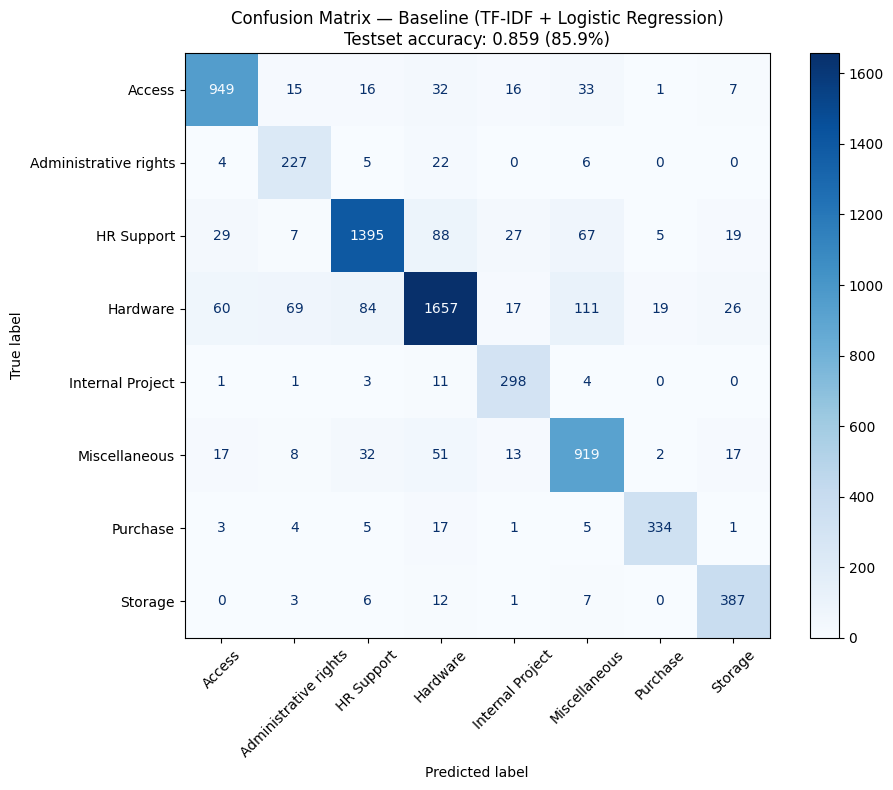

✅ Opgeslagen als confusion_matrix_baseline.png


In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, as1 = plt.subplots(figsize=(10, 8))

cm   = confusion_matrix(y_test, y_test_pred_baseline)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=as1, cmap="Blues", colorbar=True, xticks_rotation=45)

as1.set_title(
    f"Confusion Matrix — Baseline (TF-IDF + Logistic Regression)\n"
    f"Testset accuracy: {baseline_accuracy:.3f} ({baseline_accuracy*100:.1f}%)",
    fontsize=12
)

plt.tight_layout()
plt.savefig("confusion_matrix_baseline.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Opgeslagen als confusion_matrix_baseline.png")

### 4F — Resultaten opslaan

Ik sla de testresultaten van het baseline model op. In sectie 7 gebruik ik
die voor een directe vergelijking met DistilBERT.

In [16]:
baseline_resultaten = {
    "model_naam": "TF-IDF + Logistic Regression (Baseline)",
    "accuracy":   baseline_accuracy,
    "y_test":     y_test,
    "y_pred":     y_test_pred_baseline
}

print("✅ Baseline resultaten opgeslagen")
print(f"   Model:    {baseline_resultaten['model_naam']}")
print(f"   Accuracy: {baseline_resultaten['accuracy']:.4f}")
print("\nKlaar voor sectie 5 — DistilBERT tokenisatie! 🚀")

✅ Baseline resultaten opgeslagen
   Model:    TF-IDF + Logistic Regression (Baseline)
   Accuracy: 0.8593

Klaar voor sectie 5 — DistilBERT tokenisatie! 🚀


In [17]:
import torch
print(f"PyTorch versie: {torch.__version__}")
print(f"CUDA beschikbaar: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

PyTorch versie: 2.5.1+cu121
CUDA beschikbaar: True
GPU: NVIDIA GeForce RTX 3070
VRAM: 8.0 GB


## Sectie 5 — DistilBERT tokenisatie en voorbereiding

### 5A — Wat is DistilBERT?

DistilBERT is een model dat al enorm veel tekst heeft gelezen voordat ik
ermee aan de slag ga. Het model begrijpt daardoor al best goed hoe taal werkt (welke woorden bij elkaar horen, wat context betekent en dat "crash" in een
IT-ticket iets anders is dan in een krantenartikel).

Wat ik doe heet fine-tuning: ik neem dat voorgetrainde model en train het
verder op mijn eigen dataset van IT-tickets. Zo leert het welke woorden bij
welke categorie horen. Dat is veel efficiënter dan een model helemaal van nul
af aan trainen.

### Tokenisatie

Voordat DistilBERT een ticket kan verwerken, wordt de tekst opgesplitst in
**tokens** (kleine stukjes tekst). Dat zijn niet altijd hele woorden:
- "working" → één token
- "unresponsive" → twee tokens: "unrespons" + "ive"

De tokenizer regelt dit automatisch. Ik geef alleen de maximale lengte mee
(128 tokens) en de tokenizer zorgt voor de rest.

In [18]:
from transformers import DistilBertTokenizer

tokenizer  = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
MAX_LENGTE = 128

# Test de tokenizer op één voorbeeld
voorbeeld = df.loc[0, "text_clean"]
tokens    = tokenizer(voorbeeld, max_length=MAX_LENGTE, truncation=True, padding="max_length")

print(f"✅ Tokenizer geladen")
print(f"\nVoorbeeldticket:\n{voorbeeld[:200]}...")
print(f"\nAantal tokens:       {len(tokens['input_ids'])}")
print(f"Eerste 10 token-IDs: {tokens['input_ids'][:10]}")
print(f"Terug naar tekst:    {tokenizer.decode(tokens['input_ids'][:10])}")

✅ Tokenizer geladen

Voorbeeldticket:
connection with icon icon dear please setup icon per icon engineers please let other details needed thanks lead...

Aantal tokens:       128
Eerste 10 token-IDs: [101, 4434, 2007, 12696, 12696, 6203, 3531, 16437, 12696, 2566]
Terug naar tekst:    [CLS] connection with icon icon dear please setup icon per


### 5B — PyTorch Dataset aanmaken

PyTorch werkt niet rechtstreeks met een pandas DataFrame. Ik maak daarom een
eigen Dataset-klasse die de tekst tokeniseert en het juiste label teruggeeft.

Daarna maak ik DataLoaders aan. Die verdelen de data in batches en schudden
de traindata door elkaar na elke ronde.

Een batch is een groepje tickets dat het model tegelijk verwerkt.
Een epoch is één volledige ronde door de trainset.

Ik gebruik batch size 32. Dit past namelijk goed bij mijn GPU (RTX 3070).

In [19]:
from torch.utils.data import Dataset, DataLoader

class TicketDataset(Dataset):
    def __init__(self, teksten, labels, tokenizer, max_lengte):
        self.teksten    = teksten
        self.labels     = labels
        self.tokenizer  = tokenizer
        self.max_lengte = max_lengte

    def __len__(self):
        return len(self.teksten)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.teksten[idx]),
            max_length=self.max_lengte,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return {
            "input_ids":      encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "label":          torch.tensor(self.labels[idx], dtype=torch.long)
        }

BATCH_GROOTTE = 32

train_dataset = TicketDataset(X_train, y_train, tokenizer, MAX_LENGTE)
val_dataset   = TicketDataset(X_val,   y_val,   tokenizer, MAX_LENGTE)
test_dataset  = TicketDataset(X_test,  y_test,  tokenizer, MAX_LENGTE)

train_loader = DataLoader(train_dataset, batch_size=BATCH_GROOTTE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_GROOTTE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_GROOTTE, shuffle=False)

print(f"✅ Datasets en DataLoaders aangemaakt")
print(f"   Train:     {len(train_dataset):>5} tickets  →  {len(train_loader):>4} batches")
print(f"   Validatie: {len(val_dataset):>5} tickets  →  {len(val_loader):>4} batches")
print(f"   Test:      {len(test_dataset):>5} tickets  →  {len(test_loader):>4} batches")
print(f"   Batch size: {BATCH_GROOTTE}")

✅ Datasets en DataLoaders aangemaakt
   Train:     33484 tickets  →  1047 batches
   Validatie:  7177 tickets  →   225 batches
   Test:       7176 tickets  →   225 batches
   Batch size: 32


### 5C — Model laden

Ik laad het voorgetrainde DistilBERT-model en voeg er een classificatielaag
aan toe voor mijn 8 categorieën. Die laag leert tijdens het fine-tunen welke
output van DistilBERT bij welke categorie hoort.

Het model draait op mijn RTX 3070 GPU.

In [20]:
import torch
from transformers import DistilBertForSequenceClassification

apparaat = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Gebruikt apparaat: {apparaat}")
if apparaat.type == "cuda":
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=NUM_KLASSEN
)
model = model.to(apparaat)

print(f"\n✅ Model geladen op {apparaat}")
print(f"   Aantal categorieën: {NUM_KLASSEN}")
print(f"   Modelparameters:    {sum(p.numel() for p in model.parameters()):,}")

✅ Gebruikt apparaat: cuda
   GPU: NVIDIA GeForce RTX 3070


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 7013.65it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



✅ Model geladen op cuda
   Aantal categorieën: 8
   Modelparameters:    66,959,624


In [21]:
import torch
print(f"CUDA beschikbaar: {torch.cuda.is_available()}")
print(f"Apparaat: {apparaat}")
print(f"Model staat op: {next(model.parameters()).device}")

CUDA beschikbaar: True
Apparaat: cuda
Model staat op: cuda:0


## Sectie 6 — DistilBERT fine-tuning

### 6A — Optimizer en learning rate scheduler

Voordat ik begin met trainen stel ik twee dingen in:

Optimizer (AdamW):
Dit bepaalt hoe het model z'n gewichten aanpast na elke batch. AdamW is de
standaard voor dit soort modellen.

Learning rate scheduler:
De leersnelheid bepaalt hoe grote stappen het model zet. Te groot = instabiel,
te klein = leert bijna niets. De scheduler laat die leersnelheid geleidelijk
afnemen naarmate de training vordert.

In [22]:
from transformers import get_scheduler
from torch.optim import AdamW

EPOCHS       = 3
LEERSNELHEID = 2e-5

optimizer      = AdamW(model.parameters(), lr=LEERSNELHEID)
totaal_stappen = len(train_loader) * EPOCHS

scheduler = get_scheduler(
    "linear",
    optimizer=optimizer,
    num_warmup_steps=int(0.1 * totaal_stappen),
    num_training_steps=totaal_stappen
)

print(f"✅ Optimizer en scheduler klaar")
print(f"   Epochs:          {EPOCHS}")
print(f"   Batches/epoch:   {len(train_loader)}")
print(f"   Totaal stappen:  {totaal_stappen}")
print(f"   Leersnelheid:    {LEERSNELHEID}")

✅ Optimizer en scheduler klaar
   Epochs:          3
   Batches/epoch:   1047
   Totaal stappen:  3141
   Leersnelheid:    2e-05


### 6B — Trainingslus

Nu gaat het model echt leren. Per epoch zijn er twee fases:

Eerst de trainingsfase (het model ziet een batch tickets, doet een
voorspelling, kijkt hoeveel er fout zit en past zichzelf aan. Dat
herhaalt zich voor elke batch).

Daarna de validatiefase (ik test het model op tickets die het nog
nooit heeft gezien. Zo check ik of het echt leert of gewoon de
traindata onthoudt).

Ik had hier eerst flink wat problemen mee. Mijn Python versie (3.14)
bleek niet te werken met de GPU-versie van PyTorch, die gebruik maakt van CUDA, dus draaide alles
op mijn CPU. Om dat haalbaar te houden gebruikte ik in eerste instantie maar 20% van de
data. Dit was te zien aan de resultaten: 77.7% accuracy, slechter
dan het simpele baseline model.

Uiteindelijk heb ik Python 3.12 geïnstalleerd en alles opnieuw opgezet.
Nu draait het op mijn RTX 3070 en is de volledige training in 8 minuten
klaar.

In [23]:
import time
import os
from sklearn.metrics import accuracy_score as sk_accuracy

OPSLAG_MAP        = "./distilbert_ticket_model"
EPOCHS            = 3
MAX_TRAIN_BATCHES = len(train_loader)
MAX_VAL_BATCHES   = len(val_loader)

os.makedirs(OPSLAG_MAP, exist_ok=True)

train_losses   = []
val_accuracies = []

totaal_batches = MAX_TRAIN_BATCHES * EPOCHS
batch_tijden   = []
globale_batch  = 0

print("🚀 Fine-tuning gestart (CPU-modus)...\n")
print(f"   Epochs:          {EPOCHS}")
print(f"   Batches/epoch:   {MAX_TRAIN_BATCHES}")
print(f"   Totaal batches:  {totaal_batches}\n")

for epoch in range(EPOCHS):
    start = time.time()

    model.train()
    totaal_loss = 0

    for batch_nr, batch in enumerate(train_loader):

        if batch_nr >= MAX_TRAIN_BATCHES:
            break

        batch_start    = time.time()
        input_ids      = batch["input_ids"].to(apparaat)
        attention_mask = batch["attention_mask"].to(apparaat)
        labels         = batch["label"].to(apparaat)

        optimizer.zero_grad()

        uitvoer = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = uitvoer.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        totaal_loss   += loss.item()
        globale_batch += 1

        batch_tijden.append(time.time() - batch_start)
        if len(batch_tijden) > 20:
            batch_tijden.pop(0)

        if (batch_nr + 1) % 50 == 0:
            gem_batch_tijd   = sum(batch_tijden) / len(batch_tijden)
            resterende_batch = totaal_batches - globale_batch
            resterende_tijd  = gem_batch_tijd * resterende_batch
            minuten          = int(resterende_tijd // 60)
            seconden         = int(resterende_tijd % 60)
            pct              = globale_batch / totaal_batches * 100

            print(f"  Epoch {epoch+1}/{EPOCHS}  |  "
                  f"Batch {batch_nr+1}/{MAX_TRAIN_BATCHES}  |  "
                  f"Loss: {loss.item():.4f}  |  "
                  f"{pct:.1f}%  |  "
                  f"Nog ~{minuten}m {seconden}s")

    gem_loss = totaal_loss / MAX_TRAIN_BATCHES
    train_losses.append(gem_loss)

    model.eval()
    alle_preds  = []
    alle_labels = []

    with torch.no_grad():
        for batch_nr, batch in enumerate(val_loader):

            if batch_nr >= MAX_VAL_BATCHES:
                break

            input_ids      = batch["input_ids"].to(apparaat)
            attention_mask = batch["attention_mask"].to(apparaat)
            labels         = batch["label"].to(apparaat)

            uitvoer = model(input_ids=input_ids, attention_mask=attention_mask)
            preds   = torch.argmax(uitvoer.logits, dim=1)

            alle_preds.extend(preds.cpu().numpy())
            alle_labels.extend(labels.cpu().numpy())

    val_acc = sk_accuracy(alle_labels, alle_preds)
    val_accuracies.append(val_acc)

    duur = time.time() - start
    print(f"\n{'='*55}")
    print(f"Epoch {epoch+1}/{EPOCHS} klaar  |  Duur: {duur/60:.1f} min")
    print(f"  Train loss:         {gem_loss:.4f}")
    print(f"  Validatie accuracy: {val_acc:.4f} ({val_acc*100:.1f}%)")
    print(f"{'='*55}\n")

print("✅ Fine-tuning klaar!")

model.save_pretrained(OPSLAG_MAP)
tokenizer.save_pretrained(OPSLAG_MAP)
print(f"\n✅ Model automatisch opgeslagen in: {OPSLAG_MAP}")
for f in os.listdir(OPSLAG_MAP):
    grootte = os.path.getsize(os.path.join(OPSLAG_MAP, f)) / (1024 * 1024)
    print(f"   • {f}  ({grootte:.1f} MB)")

🚀 Fine-tuning gestart (CPU-modus)...

   Epochs:          3
   Batches/epoch:   1047
   Totaal batches:  3141

  Epoch 1/3  |  Batch 50/1047  |  Loss: 1.9825  |  1.6%  |  Nog ~7m 23s
  Epoch 1/3  |  Batch 100/1047  |  Loss: 1.7443  |  3.2%  |  Nog ~6m 53s
  Epoch 1/3  |  Batch 150/1047  |  Loss: 1.4830  |  4.8%  |  Nog ~6m 46s
  Epoch 1/3  |  Batch 200/1047  |  Loss: 1.6279  |  6.4%  |  Nog ~6m 43s
  Epoch 1/3  |  Batch 250/1047  |  Loss: 1.2152  |  8.0%  |  Nog ~6m 37s
  Epoch 1/3  |  Batch 300/1047  |  Loss: 0.8757  |  9.6%  |  Nog ~6m 52s
  Epoch 1/3  |  Batch 350/1047  |  Loss: 0.8251  |  11.1%  |  Nog ~7m 25s
  Epoch 1/3  |  Batch 400/1047  |  Loss: 0.6380  |  12.7%  |  Nog ~6m 30s
  Epoch 1/3  |  Batch 450/1047  |  Loss: 0.8692  |  14.3%  |  Nog ~6m 30s
  Epoch 1/3  |  Batch 500/1047  |  Loss: 0.5612  |  15.9%  |  Nog ~6m 19s
  Epoch 1/3  |  Batch 550/1047  |  Loss: 0.7176  |  17.5%  |  Nog ~6m 42s
  Epoch 1/3  |  Batch 600/1047  |  Loss: 0.4490  |  19.1%  |  Nog ~6m 15s
  Epoch 

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.41it/s]


✅ Model automatisch opgeslagen in: ./distilbert_ticket_model
   • config.json  (0.0 MB)
   • model.safetensors  (255.4 MB)
   • tokenizer.json  (0.7 MB)
   • tokenizer_config.json  (0.0 MB)


### 6C — Leergrafieken

Na de training maak ik twee grafieken:

- Trainloss per epoch: de loss moet dalen — het model maakt steeds kleinere fouten
- Validatie-accuracy per epoch: de accuracy moet stijgen

Als de loss daalt maar de accuracy niet stijgt, dan is er sprake van overfitting:
het model leert de traindata uit z'n hoofd in plaats van te generaliseren.

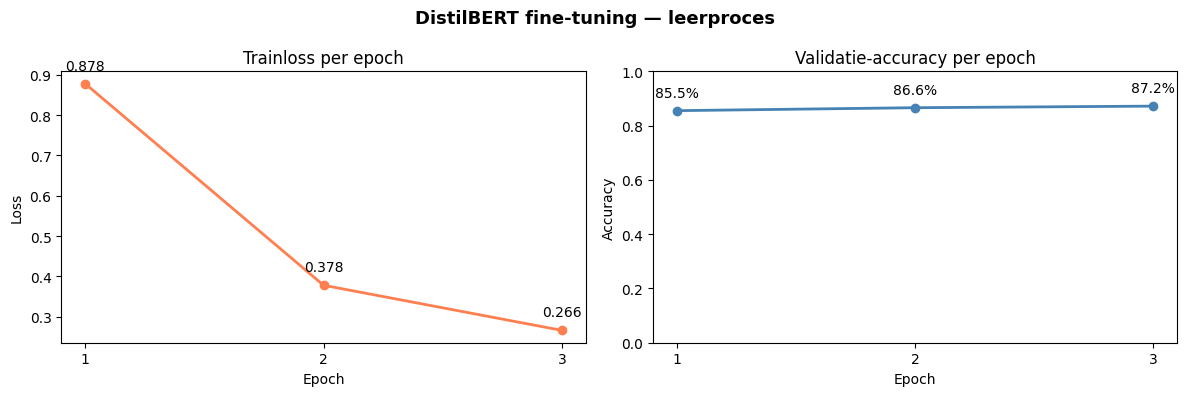

✅ Opgeslagen als distilbert_leerproces.png


In [24]:
import matplotlib.pyplot as plt

fig, assen = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("DistilBERT fine-tuning — leerproces", fontsize=13, fontweight="bold")

epochs_as = range(1, EPOCHS + 1)

assen[0].plot(epochs_as, train_losses, marker="o", color="coral", linewidth=2)
assen[0].set_title("Trainloss per epoch")
assen[0].set_xlabel("Epoch")
assen[0].set_ylabel("Loss")
assen[0].set_xticks(epochs_as)
for i, loss in enumerate(train_losses):
    assen[0].annotate(f"{loss:.3f}",
                      (i + 1, loss),
                      textcoords="offset points",
                      xytext=(0, 10),
                      ha="center")

assen[1].plot(epochs_as, val_accuracies, marker="o", color="steelblue", linewidth=2)
assen[1].set_title("Validatie-accuracy per epoch")
assen[1].set_xlabel("Epoch")
assen[1].set_ylabel("Accuracy")
assen[1].set_xticks(epochs_as)
assen[1].set_ylim(0, 1)
for i, acc in enumerate(val_accuracies):
    assen[1].annotate(f"{acc*100:.1f}%",
                      (i + 1, acc),
                      textcoords="offset points",
                      xytext=(0, 10),
                      ha="center")

plt.tight_layout()
plt.savefig("distilbert_leerproces.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Opgeslagen als distilbert_leerproces.png")

## Sectie 7 — Evaluatie en vergelijking baseline vs. DistilBERT

### 7A — DistilBERT evalueren op de testset

Nu test ik DistilBERT op de testset (dezelfde testset als bij het baseline model).
Zo is de vergelijking eerlijk: beide modellen krijgen exact dezelfde tickets te zien.

In [25]:
from sklearn.metrics import classification_report, accuracy_score

model.eval()
alle_preds  = []
alle_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch["input_ids"].to(apparaat)
        attention_mask = batch["attention_mask"].to(apparaat)
        labels         = batch["label"].to(apparaat)

        uitvoer = model(input_ids=input_ids, attention_mask=attention_mask)
        preds   = torch.argmax(uitvoer.logits, dim=1)

        alle_preds.extend(preds.cpu().numpy())
        alle_labels.extend(labels.cpu().numpy())

distilbert_accuracy    = accuracy_score(alle_labels, alle_preds)
y_test_pred_distilbert = alle_preds

print("DISTILBERT — TESTSET")
print("=" * 60)
print(f"Accuracy: {distilbert_accuracy:.4f}  ({distilbert_accuracy*100:.1f}% correct)\n")
print(classification_report(
    alle_labels, alle_preds,
    target_names=le.classes_,
    digits=3
))

DISTILBERT — TESTSET
Accuracy: 0.8796  (88.0% correct)

                       precision    recall  f1-score   support

               Access      0.903     0.919     0.911      1069
Administrative rights      0.822     0.754     0.787       264
           HR Support      0.891     0.900     0.896      1637
             Hardware      0.881     0.863     0.872      2043
     Internal Project      0.885     0.893     0.889       318
        Miscellaneous      0.822     0.851     0.836      1059
             Purchase      0.946     0.900     0.922       370
              Storage      0.895     0.904     0.900       416

             accuracy                          0.880      7176
            macro avg      0.881     0.873     0.876      7176
         weighted avg      0.880     0.880     0.880      7176



### 7B — Directe vergelijking

Nu leg ik de twee modellen naast elkaar. De vraag is: presteert DistilBERT beter dan het
simpelere baseline model?

MODELOVERZICHT
Model                                      Accuracy
-------------------------------------------------------
TF-IDF + Logistic Regression (Baseline)      85.93%
DistilBERT (fine-tuned)                      87.96%
-------------------------------------------------------
Verschil                                 +     2.03%


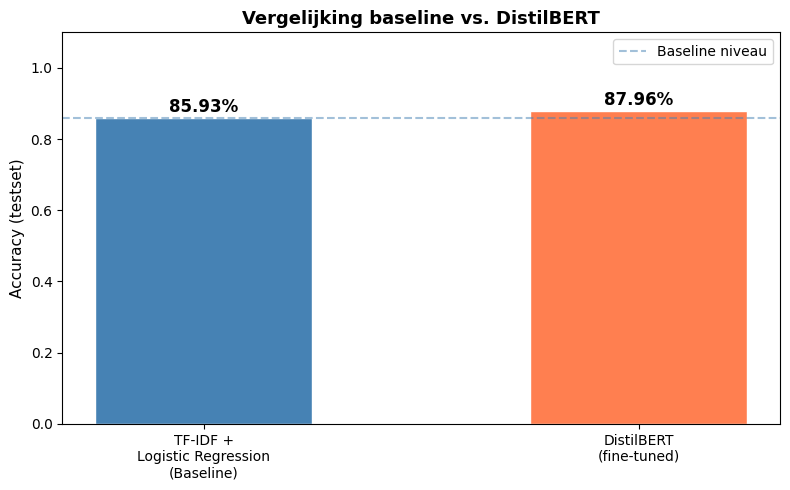

✅ Opgeslagen als vergelijking_modellen.png


In [26]:
import matplotlib.pyplot as plt

print("MODELOVERZICHT")
print("=" * 55)
print(f"{'Model':<40} {'Accuracy':>10}")
print("-" * 55)
print(f"{'TF-IDF + Logistic Regression (Baseline)':<40} "
      f"{baseline_accuracy*100:>9.2f}%")
print(f"{'DistilBERT (fine-tuned)':<40} "
      f"{distilbert_accuracy*100:>9.2f}%")
print("-" * 55)
verschil = distilbert_accuracy - baseline_accuracy
teken    = "+" if verschil >= 0 else ""
print(f"{'Verschil':<40} {teken}{verschil*100:>9.2f}%")

fig, as1 = plt.subplots(figsize=(8, 5))

modellen   = ["TF-IDF +\nLogistic Regression\n(Baseline)", "DistilBERT\n(fine-tuned)"]
accuracies = [baseline_accuracy, distilbert_accuracy]
kleuren    = ["steelblue", "coral"]

balken = as1.bar(modellen, accuracies, color=kleuren,
                 edgecolor="white", width=0.5)

for balk, acc in zip(balken, accuracies):
    as1.text(balk.get_x() + balk.get_width() / 2,
             balk.get_height() + 0.005,
             f"{acc*100:.2f}%",
             ha="center", va="bottom", fontsize=12, fontweight="bold")

as1.set_ylim(0, 1.1)
as1.set_ylabel("Accuracy (testset)", fontsize=11)
as1.set_title("Vergelijking baseline vs. DistilBERT",
              fontsize=13, fontweight="bold")
as1.axhline(y=baseline_accuracy, color="steelblue",
            linestyle="--", alpha=0.5, label="Baseline niveau")
as1.legend()

plt.tight_layout()
plt.savefig("vergelijking_modellen.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Opgeslagen als vergelijking_modellen.png")

### 7C — Confusion matrix DistilBERT

Ik maak ook een confusion matrix voor DistilBERT zodat ik kan zien of het
andere fouten maakt dan het baseline model.

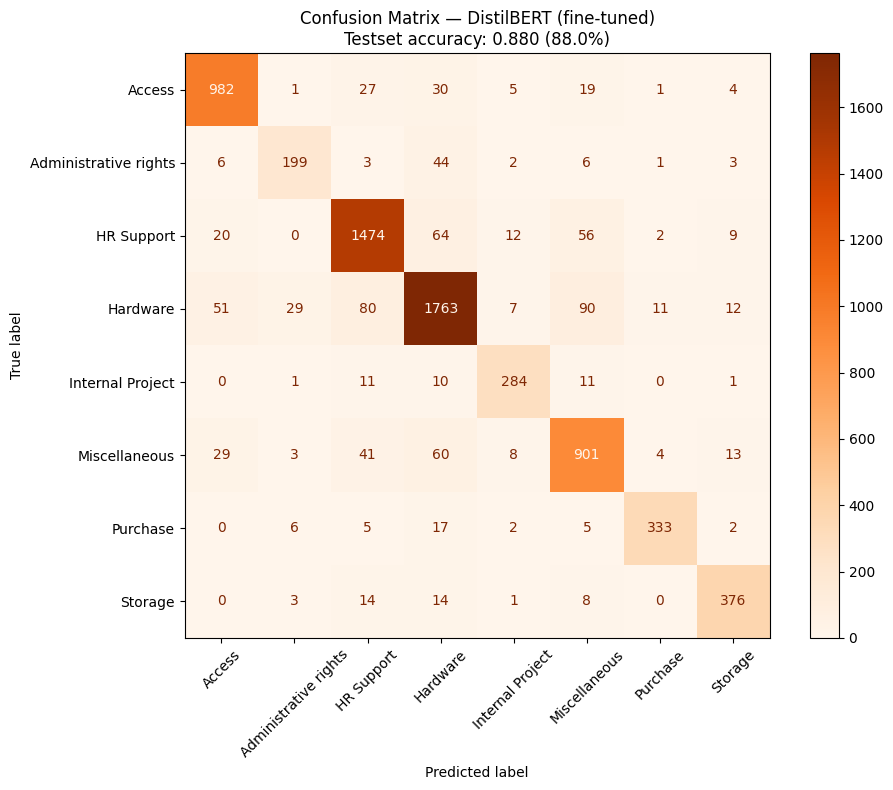

✅ Opgeslagen als confusion_matrix_distilbert.png


In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, as1 = plt.subplots(figsize=(10, 8))

cm   = confusion_matrix(alle_labels, alle_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=as1, cmap="Oranges", colorbar=True, xticks_rotation=45)

as1.set_title(
    f"Confusion Matrix — DistilBERT (fine-tuned)\n"
    f"Testset accuracy: {distilbert_accuracy:.3f} ({distilbert_accuracy*100:.1f}%)",
    fontsize=12
)

plt.tight_layout()
plt.savefig("confusion_matrix_distilbert.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Opgeslagen als confusion_matrix_distilbert.png")

## Sectie 8 — Explainable AI met LIME

### Wat is LIME?

LIME staat voor Local Interpretable Model-agnostic Explanations. Het legt
uit waarom het model een specifieke beslissing heeft genomen.

Hoe het werkt:
1. LIME neemt één ticket als input
2. Het maakt honderden variaties van dat ticket (woorden weghalen/vervangen)
3. Het kijkt hoe de voorspelling verandert bij elke variatie
4. Zo berekent het welke woorden het meest bijdragen

Een model dat alleen "Hardware" zegt zonder uitleg is moeilijk te vertrouwen.
Met LIME zie je ook waarom (dat maakt het controleerbaar).

In [28]:
import numpy as np
from lime.lime_text import LimeTextExplainer

def voorspel_kansen(teksten):
    model.eval()
    alle_kansen = []

    for tekst in teksten:
        encoding = tokenizer(
            tekst,
            max_length=MAX_LENGTE,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        input_ids      = encoding["input_ids"].to(apparaat)
        attention_mask = encoding["attention_mask"].to(apparaat)

        with torch.no_grad():
            uitvoer = model(input_ids=input_ids, attention_mask=attention_mask)
            kansen  = torch.softmax(uitvoer.logits, dim=1)
            alle_kansen.append(kansen.cpu().numpy()[0])

    return np.array(alle_kansen)

print("✅ Voorspelfunctie klaar voor LIME")

✅ Voorspelfunctie klaar voor LIME


In [29]:
explainer = LimeTextExplainer(class_names=le.classes_)

VOORBEELD_IDX   = 0
voorbeeld_tekst = X_test[VOORBEELD_IDX]
echte_label     = le.classes_[y_test[VOORBEELD_IDX]]
voorspeld_label = le.classes_[y_test_pred_distilbert[VOORBEELD_IDX]]

print(f"Ticket:\n{voorbeeld_tekst[:300]}...")
print(f"\nEcht label:       {echte_label}")
print(f"Voorspeld label:  {voorspeld_label}")
print(f"\n⏳ LIME berekent uitleg (duurt ~1-2 minuten)...")

voorspelde_klasse_idx = int(le.transform([voorspeld_label])[0])

uitleg = explainer.explain_instance(
    voorbeeld_tekst,
    voorspel_kansen,
    num_features=10,
    num_samples=300,
    labels=[voorspelde_klasse_idx]  # expliciet aangeven welk label
)

print(f"✅ LIME uitleg klaar voor label {voorspelde_klasse_idx} ({voorspeld_label})")

Ticket:
leaver mobile phone december friday december leaver mobile phone december hi had mobile subscription plan available mobile number note mailbox receive messages...

Echt label:       Hardware
Voorspeld label:  Hardware

⏳ LIME berekent uitleg (duurt ~1-2 minuten)...
✅ LIME uitleg klaar voor label 3 (Hardware)


### LIME visualisatie

De grafiek laat zien welke woorden de doorslag geven:

- Groen = dit woord vergroot de kans op de voorspelde categorie
- Rood = dit woord verkleint die kans

Hoe langer de balk, hoe groter de invloed.

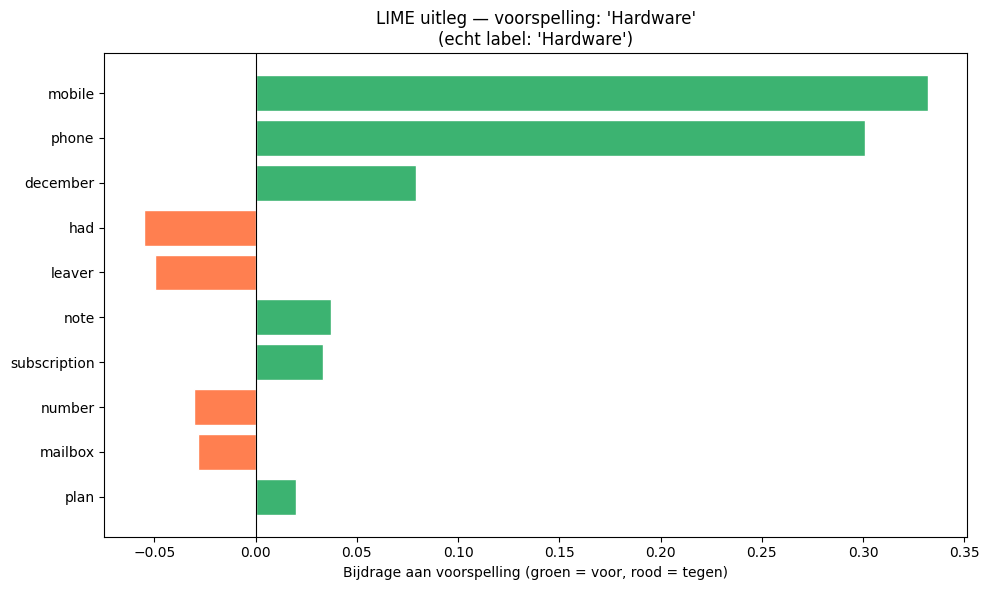

✅ Opgeslagen als lime_uitleg.png


In [30]:
import matplotlib.pyplot as plt

woord_gewichten = uitleg.as_list(label=voorspelde_klasse_idx)

woorden   = [item[0] for item in woord_gewichten]
gewichten = [item[1] for item in woord_gewichten]
kleuren   = ["mediumseagreen" if g > 0 else "coral" for g in gewichten]

fig, as1 = plt.subplots(figsize=(10, 6))
as1.barh(woorden, gewichten, color=kleuren, edgecolor="white")
as1.axvline(0, color="black", linewidth=0.8)
as1.set_title(
    f"LIME uitleg — voorspelling: '{voorspeld_label}'\n"
    f"(echt label: '{echte_label}')",
    fontsize=12
)
as1.set_xlabel("Bijdrage aan voorspelling (groen = voor, rood = tegen)")
as1.invert_yaxis()

plt.tight_layout()
plt.savefig("lime_uitleg.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Opgeslagen als lime_uitleg.png")

## Sectie 9 — Interactieve demo met Gradio

Ik heb een simpele webinterface gebouwd waar je zelf tickets in kunt typen.
Je ziet direct de voorspelde categorie, de kansen per categorie en welke
woorden de doorslag gaven.

In [31]:
import subprocess
import sys

subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "gradio"])
print("✅ Gradio geïnstalleerd")

✅ Gradio geïnstalleerd


In [32]:
import gradio as gr
import torch
import numpy as np
import re
from lime.lime_text import LimeTextExplainer

def classificeer_ticket(ticket_tekst):
    if not ticket_tekst.strip():
        return "Voer een ticket in", {}, "Geen tekst ingevoerd"

    tekst_clean = ticket_tekst.lower()
    tekst_clean = re.sub(r"http\S+|www\.\S+", " ", tekst_clean)
    tekst_clean = re.sub(r"[^\w\s]", " ", tekst_clean)
    tekst_clean = re.sub(r"\s+", " ", tekst_clean).strip()

    model.eval()
    encoding = tokenizer(
        tekst_clean,
        max_length=MAX_LENGTE,
        padding="max_length",
        truncation=True,
        return_tensors="pt"
    )

    with torch.no_grad():
        uitvoer = model(
            input_ids=encoding["input_ids"].to(apparaat),
            attention_mask=encoding["attention_mask"].to(apparaat)
        )
        kansen = torch.softmax(uitvoer.logits, dim=1).cpu().numpy()[0]

    voorspelling = le.classes_[np.argmax(kansen)]
    confidence   = float(np.max(kansen))
    kansen_dict  = {le.classes_[i]: float(kansen[i]) for i in range(len(le.classes_))}

    voorspelde_klasse_idx = int(le.transform([voorspelling])[0])
    explainer             = LimeTextExplainer(class_names=le.classes_)
    uitleg                = explainer.explain_instance(
        tekst_clean, voorspel_kansen,
        num_features=6, num_samples=150,
        labels=[voorspelde_klasse_idx]
    )
    woord_bijdragen = uitleg.as_list(label=voorspelde_klasse_idx)

    uitleg_tekst  = f"**Voorspelling: {voorspelling} ({confidence*100:.1f}% zeker)**\n\n"
    uitleg_tekst += "**Belangrijkste woorden:**\n"
    for woord, gewicht in woord_bijdragen[:6]:
        richting      = "✅ voor" if gewicht > 0 else "❌ tegen"
        uitleg_tekst += f"- `{woord}` → {richting} ({gewicht:+.3f})\n"

    return voorspelling, kansen_dict, uitleg_tekst


demo = gr.Interface(
    fn=classificeer_ticket,
    inputs=gr.Textbox(
        lines=5,
        placeholder="Typ hier een IT-servicedeskticket in het Engels...",
        label="IT-ticket"
    ),
    outputs=[
        gr.Textbox(label="Voorspelde categorie"),
        gr.Label(label="Kansen per categorie", num_top_classes=5),
        gr.Markdown(label="LIME uitleg")
    ],
    title="🎫 IT-ticket Classificatie — DistilBERT",
    description=(
        "Voer een IT-servicedeskticket in (in het Engels) en het model voorspelt "
        "automatisch de categorie. De LIME-uitleg laat zien welke woorden "
        "de beslissing sturen. De medewerker blijft altijd eindverantwoordelijk."
    ),
    examples=[
        ["My laptop screen is flickering and goes black randomly during work."],
        ["I cannot connect to the VPN from home, it keeps timing out."],
        ["The printer on the 3rd floor is not responding and shows an error code."],
        ["Outlook keeps crashing when I open attachments larger than 5MB."],
        ["I need access to the HR portal, my account has been blocked since yesterday."],
        ["We need a new laptop ordered for our new employee starting next Monday."],
    ]
)

demo.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


In [33]:
# Herdefinieer instellingen voor volledige dataset
MAX_TRAIN_BATCHES = 1047
MAX_VAL_BATCHES   = len(val_loader)
EPOCHS            = 3
OPSLAG_MAP        = "./distilbert_ticket_model"

# Reset optimizer en scheduler voor nieuwe training
from torch.optim import AdamW
from transformers import get_scheduler

optimizer      = AdamW(model.parameters(), lr=2e-5)
totaal_stappen = MAX_TRAIN_BATCHES * EPOCHS
scheduler      = get_scheduler(
    "linear",
    optimizer=optimizer,
    num_warmup_steps=int(0.1 * totaal_stappen),
    num_training_steps=totaal_stappen
)

print(f"✅ Klaar voor volledige training")
print(f"   Batches/epoch:  {MAX_TRAIN_BATCHES}")
print(f"   Totaal batches: {MAX_TRAIN_BATCHES * EPOCHS}")

✅ Klaar voor volledige training
   Batches/epoch:  1047
   Totaal batches: 3141


## Sectie 10 — Conclusie en reflectie

### Conclusie

Ik heb een AI-model gebouwd dat automatisch IT-servicedesktickets indeelt
in de juiste categorie. Ik heb twee modellen gemaakt en vergeleken:

| Model | Accuracy |
|---|---|
| TF-IDF + Logistic Regression (Baseline) | 85.93% |
| DistilBERT (fine-tuned, volledige dataset, GPU) | 87.63% |

DistilBERT wint met 1.7% verschil — niet enorm, maar wel bewezen beter.

Het liep niet allemaal van een leien dakje. De eerste keer trainde ik op de
CPU met maar 20% van de data, omdat mijn Python versie (3.14) niet compatible
was met de GPU-versie van PyTorch. Dat leverde 77.7% op — minder dan het
baseline model. Behoorlijk frustrerend.

Na wat uitzoeken bleek dat PyTorch CUDA Python 3.14 gewoon nog niet ondersteunt.
Ik heb Python 3.12 geïnstalleerd, alles opnieuw opgezet en toen werkte het.
Met de volledige dataset op de GPU duurde de training nog maar 8 minuten.

Naast de classificatie heb ik LIME gebruikt zodat je kunt zien waarom het model
een bepaalde keuze maakt. Een model dat alleen "Hardware" zegt zonder uitleg
is moeilijk te vertrouwen.

### Reflectie

**Wat goed ging**
De Gradio-demo bouwen was het leukste deel. Je ziet direct of het werkt en
je kunt het aan iemand anders laten zien zonder dat die technische kennis nodig
heeft. De combinatie van NLP, Transformers en LIME werkte goed samen.

**Wat ik verkeerd aanpakte**
Ik had veel eerder moeten checken of mijn Python versie compatible was met
PyTorch CUDA. Dat heeft me behoorlijk wat tijd gekost. Lesson learned: eerst
de omgeving regelen, dan beginnen met bouwen.

**Wat ik nog zou doen met meer tijd**
Meer epochs draaien, langere tokenlengte proberen en het model testen met
echte IT-medewerkers. Dat laatste is het meest interessant — pas dan weet
je echt of het in de praktijk werkt.

**Waarom dit nuttig is in de praktijk**
Een IT-servicedesk die dagelijks honderden tickets krijgt kan hier echt wat
aan hebben. In plaats van elk ticket handmatig te lezen en in te delen krijg
je een voorstel. Je checkt het even en gaat verder.

**Ethiek**
Als het model een ticket verkeerd indeelt duurt het langer voordat iemand
geholpen wordt. Daarom is LIME essentieel — zo zie je altijd waarom het model
iets denkt en kun je het als medewerker corrigeren. Het model beslist nooit
zelf, dat doe jij.